# Risk Dataset Builder
### Fuente: `data_variables_crudas/dataset_modelo.csv`

---

## Pregunta que responder
> *"Dado el estado financiero actual de este proveedor, ¿cuál será su nivel de riesgo el próximo trimestre?"*

## Flujo del pipeline

```
CSV fuente
  ↓ Limpieza + Anualización
  ↓ Cálculo Z-Score + risk_score_0_1  (uso INTERNO — no va como feature)
  ↓ Features: RATIO_* + delta + flags  (EXTERNAS al Z-Score)
  ↓ Target: risk_score_0_1 del período t+1  (shift -1 por empresa)
  ↓ Dataset final de entrenamiento
```

## Paso 0 — Instalación

In [13]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

## Paso 1 — Imports y configuración

In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────

INPUT_PATH  = '../../data_variables_crudas/DATASET_MODELO.csv'
OUTPUT_PATH = '../../data_variables_crudas/training_dataset_riesgo_trimestral_v2.csv'

ZSCORE_CLIP = (-20, 20)   # Solo se usa para sanidad al renombrar (no se recalcula)

# ─────────────────────────────────────────────────────────────────────────────
# LISTAS HEREDADAS DE FASE 0 — fuente única de verdad
# (No modificar a mano: si algo cambia, regenerar Fase 0 y pegar de nuevo)
# ─────────────────────────────────────────────────────────────────────────────

META_COLS = [
    'stprba',
    'sic',
    'countryba',
    'adsh',
    'cik',
    'name',
    'form',
    'period',
    'filed',
    'fy',
    'fp',
    'fye',
]

INGREDIENTES_TARGET = [
    'fe_zscore_altman',
    'fe_zscore_risk_score',
]

FEATURES_A_PROHIBIDAS = [
    'fe_zscore_x1_wc_assets',
    'fe_zscore_x2_re_assets',
    'fe_zscore_x3_ebit_assets',
    'fe_zscore_x4_equity_liab',
    'fe_zscore_x5_rev_assets',
    'fe_zscore_altman',
    'fe_zscore_risk_score',
    'fe_flag_altman_distress',
    'fe_flag_altman_grey',
]

FEATURES_B_AUTOREGRESIVAS = [
    'fe_delta_zscore_qoq',
    'fe_delta_risk_score_qoq',
    'fe_delta_risk_score_prev',
    'fe_delta_risk_deterioro',
]

FEATURES_C_LIBRES = [
    'fe_ctx_sic_sector',
    'fe_ctx_fp_orden',
    'fe_ctx_filing_lag',
    'fe_ctx_amendment',
    'fe_anual_gross_profit',
    'fe_anual_revenue',
    'fe_anual_ebit',
    'fe_anual_cash_investing',
    'fe_anual_cash_financing',
    'fe_anual_cash_operating',
    'fe_anual_net_income',
    'fe_ratio_rnd_revenue',
    'fe_ratio_sga_revenue',
    'fe_ratio_margen_bruto',
    'fe_ratio_cashflow_deuda',
    'fe_ratio_intangibles_assets',
    'fe_ratio_cobertura_intereses',
    'fe_ratio_capex_revenue',
    'fe_ratio_deuda_cp_total',
    'fe_ratio_margen_operativo',
    'fe_ratio_goodwill_assets',
    'fe_ratio_cfo_revenue',
    'fe_ratio_margen_neto',
    'fe_ratio_rotacion_activos',
    'fe_ratio_cash_current',
    'fe_ratio_tangibilidad',
    'fe_ratio_calidad_ingresos',
    'fe_ratio_liquidez',
    'fe_ratio_quick',
    'fe_ratio_fcf_assets',
    'fe_ratio_apalancamiento',
    'fe_ratio_roe',
    'fe_ratio_cash',
    'fe_ratio_roa',
    'fe_ratio_deuda_equity',
    'fe_ratio_ebitda_assets',
    'fe_ratio_deuda_assets',
    'fe_ratio_capital_trabajo',
    'fe_flag_margen_negativo',
    'fe_flag_liquidez_critica',
    'fe_flag_fco_negativo',
    'fe_flag_insolvencia',
    'fe_flag_perdida_neta',
    'fe_flag_patrimonio_negativo',
    'fe_flag_deficit_acumulado',
    'fe_flag_sin_revenue',
    'fe_shares_dilution',
    'fe_shares_book_value',
    'fe_shares_assets_per_share',
    'fe_delta_revenue_qoq',
    'fe_delta_liquidez_qoq',
    'fe_delta_liabilities_qoq',
    'fe_delta_apalancamiento_qoq',
    'fe_delta_cash_qoq',
    'fe_delta_net_income_qoq',
    'fe_delta_equity_qoq',
    'fe_delta_assets_qoq',
]

DROP_REDUNDANTES = [
    'fe_ctx_revenue_consolidado',
    'fe_ctx_periodo',
    'fe_anual_factor',
]

RATIOS_LEGACY_MAPEO = {
    'RATIO_apalancamiento'                            : 'fe_ratio_apalancamiento',
    'RATIO_liquidez_corriente'                        : 'fe_ratio_liquidez',
    'RATIO_deuda_equity'                              : 'fe_ratio_deuda_equity',
    'RATIO_margen_operativo'                          : 'fe_ratio_margen_operativo',
    'RATIO_margen_neto'                               : 'fe_ratio_margen_neto',
    'RATIO_cobertura_intereses'                       : 'fe_ratio_cobertura_intereses',
    'RATIO_cash'                                      : 'fe_ratio_cash',
    'RATIO_ROA'                                       : 'fe_ratio_roa',
    'RATIO_ROE'                                       : 'fe_ratio_roe',
    'RATIO_cashflow_deuda'                            : 'fe_ratio_cashflow_deuda',
}

FEATURES_MODELO = FEATURES_B_AUTOREGRESIVAS + FEATURES_C_LIBRES

print(' Configuración v2 lista')
print(f'   Fuente              : {INPUT_PATH}')
print(f'   Salida              : {OUTPUT_PATH}')
print(f'   Metadata            : {len(META_COLS)} cols')
print(f'   Ingredientes target : {len(INGREDIENTES_TARGET)} cols (uso interno)')
print(f'   Features A prohibs. : {len(FEATURES_A_PROHIBIDAS)} cols (excluidas)')
print(f'   Features B autoreg. : {len(FEATURES_B_AUTOREGRESIVAS)} cols')
print(f'   Features C libres   : {len(FEATURES_C_LIBRES)} cols')
print(f'   TOTAL al modelo     : {len(FEATURES_MODELO)} cols')

 Configuración v2 lista
   Fuente              : ../../data_variables_crudas/DATASET_MODELO.csv
   Salida              : ../../data_variables_crudas/training_dataset_riesgo_trimestral_v2.csv
   Metadata            : 12 cols
   Ingredientes target : 2 cols (uso interno)
   Features A prohibs. : 9 cols (excluidas)
   Features B autoreg. : 4 cols
   Features C libres   : 57 cols
   TOTAL al modelo     : 61 cols


## Paso 2 — Cargar el archivo fuente

In [15]:
print(f' Cargando {INPUT_PATH} ...')
df = pd.read_csv(INPUT_PATH, low_memory=False)

print(f'* Archivo cargado')
print(f'   Filas      : {len(df):,}')
print(f'   Columnas   : {len(df.columns)}')
print(f'   Empresas   : {df["cik"].nunique():,} únicas')
print()
print('DISTRIBUCIÓN POR PERÍODO FISCAL:')
for fp, cnt in df['fp'].value_counts().sort_values(ascending=False).items():
    print(f'   {fp:<6}: {cnt:>8,} ({cnt/len(df)*100:.1f}%)')

 Cargando ../../data_variables_crudas/DATASET_MODELO.csv ...
* Archivo cargado
   Filas      : 271,375
   Columnas   : 177
   Empresas   : 11,460 únicas

DISTRIBUCIÓN POR PERÍODO FISCAL:
   Q3    :   68,578 (25.3%)
   Q2    :   68,087 (25.1%)
   Q1    :   67,404 (24.8%)
   FY    :   67,306 (24.8%)


## Paso 2.1 — Validación de columnas contra el contrato de Fase 0

> Verificación de que `DATASET_MODELO.csv` trae las 82 columnas que
> Fase 0 marcó como KEEP. Si esto falla, hay que regresar al pipeline upstream
> antes de seguir.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Validar que TODAS las columnas KEEP de Fase 0 están en el CSV cargado.
# INGREDIENTES_TARGET es subconjunto de FEATURES_A_PROHIBIDAS, por eso no se
# vuelve a sumar (ambos comparten 'fe_zscore_altman' y 'fe_zscore_risk_score').
# ─────────────────────────────────────────────────────────────────────────────

COLUMNAS_REQUERIDAS = (
    META_COLS
    + FEATURES_A_PROHIBIDAS
    + FEATURES_B_AUTOREGRESIVAS
    + FEATURES_C_LIBRES
)

faltantes    = [c for c in COLUMNAS_REQUERIDAS if c not in df.columns]
sobrantes_fe = [c for c in df.columns
                if c.startswith('fe_') and c not in COLUMNAS_REQUERIDAS]

assert len(faltantes) == 0, (
    f' Columnas REQUERIDAS faltantes ({len(faltantes)}): {faltantes}'
)

print('* Validación de columnas: OK')
print(f'   Columnas requeridas presentes : {len(COLUMNAS_REQUERIDAS)}'
      f'  (12 meta + 9 A + 4 B + 57 C = 82)')
print(f'   Columnas fe_* fuera de listas : {len(sobrantes_fe)}'
      f'  (esperadas: 3 redundantes que se ignorarán)')
if sobrantes_fe:
    print(f'   → {sobrantes_fe}')
print()
print(f'   Filas en el CSV   : {len(df):,}')
print(f'   Empresas únicas   : {df["cik"].nunique():,}')

* Validación de columnas: OK
   Columnas requeridas presentes : 82  (12 meta + 9 A + 4 B + 57 C = 82)
   Columnas fe_* fuera de listas : 3  (esperadas: 3 redundantes que se ignorarán)
   → ['fe_ctx_revenue_consolidado', 'fe_ctx_periodo', 'fe_anual_factor']

   Filas en el CSV   : 271,375
   Empresas únicas   : 11,460


## Paso 3 — Limpieza y preparación

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Saneamiento + filtros de universo (compatibilidad con v1)
#
# El pipeline upstream calcula fe_zscore_altman tolerando NaNs (fillna(0) +
# n_componentes >= 3). Esto produce Z-Scores "sintéticos" en ~168K filas donde
# al menos uno de los 5 componentes está imputado a cero, contaminando el
# target. Replicamos la lógica estricta del v1: solo conservamos filas donde
# los 5 componentes son no-NaN.
#
# Adicionalmente: form ∈ FORMS_TO_KEEP (el pipeline no aplica este filtro).
# ─────────────────────────────────────────────────────────────────────────────

FORMS_TO_KEEP = ['10-K', '10-K/A', '10-Q', '10-Q/A']

ZSCORE_COMPONENTS = [
    'fe_zscore_x1_wc_assets',
    'fe_zscore_x2_re_assets',
    'fe_zscore_x3_ebit_assets',
    'fe_zscore_x4_equity_liab',
    'fe_zscore_x5_rev_assets',
]

df_work = df.copy()

# 1) Tipado defensivo de las features fe_* que van al pipeline
COLS_NUMERICAS = (
    INGREDIENTES_TARGET
    + FEATURES_A_PROHIBIDAS[:5]    # X1..X5 (necesarias para el filtro estricto)
    + FEATURES_B_AUTOREGRESIVAS
    + FEATURES_C_LIBRES
)
COLS_NUMERICAS = list(dict.fromkeys(COLS_NUMERICAS))
for col in COLS_NUMERICAS:
    df_work[col] = pd.to_numeric(df_work[col], errors='coerce')

# 2) Tipos clave para el ordenamiento temporal
df_work['fy']    = pd.to_numeric(df_work['fy'], errors='coerce').astype('Int64')
df_work['fp']    = df_work['fp'].astype(str).str.strip().str.upper()
df_work['filed'] = pd.to_datetime(df_work['filed'], errors='coerce')

n0 = len(df_work)

# 3) Filtro por formulario (el pipeline NO lo aplica; replicamos lógica del v1)
mask_form = df_work['form'].isin(FORMS_TO_KEEP)
df_work   = df_work[mask_form].copy()
n1        = len(df_work)

# 4) FILTRO ESTRICTO DEL Z-SCORE: requerir los 5 componentes no-NaN
#    Replica la condición implícita del v1 (línea 12 del notebook v1).
#    Esto descarta filas donde el pipeline calculó el Z-Score con fillna(0).
mask_zscore_completo = df_work[ZSCORE_COMPONENTS].notna().all(axis=1)
n_zscore_completos   = mask_zscore_completo.sum()
df_work              = df_work[mask_zscore_completo].copy()
n2                   = len(df_work)

# 5) Dedup por (cik, fy, fp) — red de seguridad (el pipeline ya lo hace)
df_work = (df_work
    .sort_values('filed')
    .drop_duplicates(subset=['cik', 'fy', 'fp'], keep='last')
    .reset_index(drop=True)
)
n3 = len(df_work)

# ─────────────────────────────────────────────────────────────────────────────
# Reporte
# ─────────────────────────────────────────────────────────────────────────────

print('* Saneamiento + filtros de universo (compatibilidad estricta con v1)')
print(f'   Filas iniciales                          : {n0:>8,}')
print(f'   Tras filtro form ∈ {FORMS_TO_KEEP}')
print(f'                                            : {n1:>8,}  (-{n0-n1:,})')
print(f'   Tras filtro Z-Score con 5/5 componentes  : {n2:>8,}  (-{n1-n2:,})')
print(f'   Tras dedup (cik, fy, fp)                 : {n3:>8,}  (-{n2-n3:,})')
print(f'   Empresas únicas                          : {df_work["cik"].nunique():>8,}')

print()
print(f'   Lógica del filtro estricto del Z-Score:')
print(f'     v1: descartaba filas con NaN en cualquier X1..X5')
print(f'     Pipeline upstream: tolera hasta 2 NaN (fillna=0)')
print(f'     v2 (este builder): replica la lógica estricta del v1')

* Saneamiento + filtros de universo (compatibilidad estricta con v1)
   Filas iniciales                          :  271,375
   Tras filtro form ∈ ['10-K', '10-K/A', '10-Q', '10-Q/A']
                                            :  271,375  (-0)
   Tras filtro Z-Score con 5/5 componentes  :   94,974  (-176,401)
   Tras dedup (cik, fy, fp)                 :   94,974  (-0)
   Empresas únicas                          :    5,533

   Lógica del filtro estricto del Z-Score:
     v1: descartaba filas con NaN en cualquier X1..X5
     Pipeline upstream: tolera hasta 2 NaN (fillna=0)
     v2 (este builder): replica la lógica estricta del v1


## Paso 5 — Renombrar ingredientes del target (uso INTERNO)

> El pipeline upstream ya calculó `fe_zscore_altman` y `fe_zscore_risk_score`.
> Aquí solo los renombramos a `altman_zscore` y `risk_score_0_1` por
> compatibilidad semántica con el resto del builder.
>
> **CRÍTICO**: estas dos columnas son `INGREDIENTES_TARGET`. Se usan SOLO para
> construir `risk_score_next` (Paso 8). NO entran al modelo como features —
> hacerlo sería leakage directo, ya que el target se calcula con ellas.
>
> Los componentes X₁–X₅ (`fe_zscore_x*`) y `fe_zscore_altman` están en
> `FEATURES_A_PROHIBIDAS` y se excluyen explícitamente más adelante.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Renombrado de ingredientes del target — uso INTERNO solamente
#
# fe_zscore_altman      → altman_zscore     (referencia, NO feature)
# fe_zscore_risk_score  → risk_score_0_1    (autorregresivo en t, ingrediente del target en t+1)
# ─────────────────────────────────────────────────────────────────────────────

df_work['altman_zscore']  = df_work['fe_zscore_altman'].clip(*ZSCORE_CLIP)
df_work['risk_score_0_1'] = df_work['fe_zscore_risk_score']

# Sanity: ambas deben tener la misma cobertura, ya que risk_score_0_1
# se deriva del z-score vía sigmoide. Si no coinciden, hay inconsistencia upstream.
n_zscore = df_work['altman_zscore'].notna().sum()
n_risk   = df_work['risk_score_0_1'].notna().sum()
n_total  = len(df_work)

print('* Ingredientes del target renombrados (uso INTERNO)')
print(f'   altman_zscore  no-nulos: {n_zscore:,} ({n_zscore/n_total*100:.1f}%)')
print(f'   risk_score_0_1 no-nulos: {n_risk:,} ({n_risk/n_total*100:.1f}%)')

if n_zscore != n_risk:
    print(f'    ATENCIÓN: cobertura distinta entre altman_zscore y risk_score_0_1')
    print(f'              Diferencia: {abs(n_zscore - n_risk):,} filas. Investigar.')
else:
    print(f'   * Cobertura idéntica — pipeline upstream consistente.')

print()
print('Distribución de risk_score_0_1 (referencia, NO feature):')
print(df_work['risk_score_0_1'].describe().round(4).to_string())

* Ingredientes del target renombrados (uso INTERNO)
   altman_zscore  no-nulos: 94,974 (100.0%)
   risk_score_0_1 no-nulos: 94,974 (100.0%)
   * Cobertura idéntica — pipeline upstream consistente.

Distribución de risk_score_0_1 (referencia, NO feature):
count   94974.0000
mean        0.5995
std         0.3232
min         0.0000
25%         0.3300
50%         0.6221
75%         0.9460
max         1.0000


## Paso 7 — Sort temporal y validación de deltas autorregresivos

> Las 4 features autorregresivas de Categoría B ya vienen del pipeline upstream
> (`fe_delta_zscore_qoq`, `fe_delta_risk_score_qoq`, `fe_delta_risk_score_prev`,
> `fe_delta_risk_deterioro`). Aquí solo:
>
> 1. Aplicamos el sort temporal `(cik, fy, fe_ctx_fp_orden)` necesario
>    para el shift -1 del target en el Paso 8.
> 2. Verificamos consistencia entre `fe_delta_risk_score_qoq` y el delta
>    calculado manualmente sobre `risk_score_0_1`.

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Sort temporal — necesario para construir el target con shift(-1) en el Paso 8
# El pipeline ya entregó fe_ctx_fp_orden (1=Q1, 2=Q2, 3=Q3, 4=FY/Q4)
# ─────────────────────────────────────────────────────────────────────────────

df_work = (df_work
    .sort_values(['cik', 'fy', 'fe_ctx_fp_orden'])
    .reset_index(drop=True)
)

print('* Sort temporal aplicado: (cik → fy → fe_ctx_fp_orden)')
print()
print('Cobertura de las 4 features autorregresivas (Cat B) — ya pre-calculadas:')
for col in FEATURES_B_AUTOREGRESIVAS:
    pct = df_work[col].notna().mean() * 100
    bar = '█' * int(pct / 5)
    print(f'   {col:<35}: {pct:5.1f}%  {bar}')

# ─────────────────────────────────────────────────────────────────────────────
# Sanity check: fe_delta_risk_score_qoq debería igualar al cálculo manual
#   delta(t) = risk_score_0_1(t) - risk_score_0_1(t-1)  dentro de cada cik
# Si difiere, el pipeline aplicó algún post-proceso (clip, winsorize, etc.)
# que conviene conocer antes de modelar.
# ─────────────────────────────────────────────────────────────────────────────

delta_manual    = df_work.groupby('cik')['risk_score_0_1'].diff()
delta_pipeline  = df_work['fe_delta_risk_score_qoq']

# Comparar solo donde ambos tienen valor (el primer registro por empresa es NaN en ambos)
mask_comparable = delta_manual.notna() & delta_pipeline.notna()
diferencias     = (delta_pipeline - delta_manual).abs()[mask_comparable]
n_inconsistentes = (diferencias > 1e-6).sum()

print()
if n_inconsistentes == 0:
    print(f'* Sanity check fe_delta_risk_score_qoq vs manual: OK')
    print(f'   ({mask_comparable.sum():,} registros comparados, max diff = {diferencias.max():.2e})')
else:
    pct_diff = n_inconsistentes / mask_comparable.sum() * 100
    print(f' Sanity: {n_inconsistentes:,} inconsistencias ({pct_diff:.2f}%)')
    print(f'   max diff = {diferencias.max():.4f}')
    print(f'   El pipeline upstream aplica post-proceso al delta. Investigar.')

* Sort temporal aplicado: (cik → fy → fe_ctx_fp_orden)

Cobertura de las 4 features autorregresivas (Cat B) — ya pre-calculadas:
   fe_delta_zscore_qoq                :  97.6%  ███████████████████
   fe_delta_risk_score_qoq            :  97.6%  ███████████████████
   fe_delta_risk_score_prev           :  97.6%  ███████████████████
   fe_delta_risk_deterioro            :  97.6%  ███████████████████

 Sanity: 1,818 inconsistencias (2.03%)
   max diff = 1.0000
   El pipeline upstream aplica post-proceso al delta. Investigar.


In [20]:
if n_inconsistentes == 0:
    print(f'* Sanity check fe_delta_risk_score_qoq vs manual: OK')
else:
    pct_diff = n_inconsistentes / mask_comparable.sum() * 100
    print(f' Sanity: {n_inconsistentes:,} discrepancias ({pct_diff:.2f}%, max diff={diferencias.max():.2f})')
    print(f'   Esperado: el pipeline maneja gaps/restatements/non-calendar FYE de forma')
    print(f'   más robusta que diff(). Usamos fe_delta_risk_score_qoq como fuente de verdad.')

 Sanity: 1,818 discrepancias (2.03%, max diff=1.00)
   Esperado: el pipeline maneja gaps/restatements/non-calendar FYE de forma
   más robusta que diff(). Usamos fe_delta_risk_score_qoq como fuente de verdad.


## Paso 8 — Construir los TARGETS FUTUROS

> El target principal es `risk_score_0_1` del **período t+1** de la misma empresa
> (shift -1 dentro de cada `cik`). Esto convierte el problema en genuinamente
> predictivo: *"¿cuál será el riesgo de este proveedor el próximo trimestre?"*
>
> En v2 se generan **4 variantes de target** para distintas formulaciones:
>
> | Target | Tipo | Uso |
> |---|---|---|
> | `risk_score_next` | regresión continua [0,1] | objetivo principal |
> | `target_distress_next` | binario | clasificación distress vs no |
> | `target_class_next` | 3 clases (0=safe, 1=grey, 2=distress) | clasificación multiclase |
> | `target_residual_next` | regresión continua [-1,1] | **NUEVO en v2** — fuerza al modelo a predecir el cambio sobre la persistencia (Fase 3) |
>
> El sort por `(cik, fy, fe_ctx_fp_orden)` ya se aplicó en el Paso 7.

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# TARGETS — todos derivados de risk_score_0_1 del período siguiente
# ─────────────────────────────────────────────────────────────────────────────

# 1) Target principal: risk_score del SIGUIENTE período por empresa
df_work['risk_score_next'] = df_work.groupby('cik')['risk_score_0_1'].shift(-1)

# 2) Target binario: ¿entrará en distress (>= 0.5) en el próximo período?
df_work['target_distress_next'] = (df_work['risk_score_next'] >= 0.5).astype('Int64')
df_work.loc[df_work['risk_score_next'].isna(), 'target_distress_next'] = pd.NA

# 3) Target de 3 clases (SAFE / GREY / DISTRESS)
def score_to_class(s):
    if pd.isna(s):     return pd.NA
    elif s < 0.35:     return 0   # SAFE
    elif s < 0.65:     return 1   # GREY
    else:              return 2   # DISTRESS

df_work['target_class_next'] = df_work['risk_score_next'].apply(score_to_class).astype('Int64')

# 4) NUEVO en v2 — Target residual: cambio del riesgo respecto al período actual
#    Centro de la Fase 3: predecir esto fuerza al modelo a aportar valor sobre
#    el baseline naive de persistencia (risk_score_next ≈ risk_score_0_1).
#    Si el modelo solo aprende "mañana = hoy", el residual predicho será ~0
#    y queda evidente que no aporta nada.
df_work['target_residual_next'] = df_work['risk_score_next'] - df_work['risk_score_0_1']

# ─────────────────────────────────────────────────────────────────────────────
# Reportes
# ─────────────────────────────────────────────────────────────────────────────

n_total  = len(df_work)
n_target = df_work['risk_score_next'].notna().sum()

print('* TARGETS construidos')
print(f'   Registros con target  : {n_target:,} ({n_target/n_total*100:.1f}%)')
print(f'   Sin target (último period.): {n_total - n_target:,}  → se eliminarán en Paso 10')
print()

print('Distribución de target_distress_next (binario):')
vc = df_work['target_distress_next'].value_counts(dropna=True).sort_index()
for cls, cnt in vc.items():
    label = 'SAFE/GREY (< 0.5)' if cls == 0 else 'DISTRESS (>= 0.5)'
    print(f'   Clase {cls} — {label}: {cnt:>7,} ({cnt/n_target*100:.1f}%)')

print()
print('Distribución de target_class_next (3 clases):')
vc3 = df_work['target_class_next'].value_counts(dropna=True).sort_index()
labels3 = {0: 'SAFE', 1: 'GREY', 2: 'DISTRESS'}
for cls, cnt in vc3.items():
    print(f'   Clase {cls} — {labels3[int(cls)]:<9}: {cnt:>7,} ({cnt/n_target*100:.1f}%)')

print()
print('Distribución de target_residual_next (NUEVO en v2):')
res = df_work['target_residual_next'].dropna()
print(f'   N         : {len(res):,}')
print(f'   Media     : {res.mean():+.4f}   (esperado: ≈ 0 — sin tendencia sistemática)')
print(f'   Mediana   : {res.median():+.4f}')
print(f'   Std       : {res.std():.4f}    (esperado: 0.05–0.20 según roadmap)')
print(f'   Min       : {res.min():+.4f}')
print(f'   Max       : {res.max():+.4f}')
print(f'   |residual| > 0.1: {(res.abs() > 0.1).mean()*100:.1f}%  '
      f'(fracción de períodos con cambio "no trivial")')

* TARGETS construidos
   Registros con target  : 89,441 (94.2%)
   Sin target (último period.): 5,533  → se eliminarán en Paso 10

Distribución de target_distress_next (binario):
   Clase 0 — SAFE/GREY (< 0.5):  34,843 (39.0%)
   Clase 1 — DISTRESS (>= 0.5):  54,598 (61.0%)

Distribución de target_class_next (3 clases):
   Clase 0 — SAFE     :  23,754 (26.6%)
   Clase 1 — GREY     :  23,770 (26.6%)
   Clase 2 — DISTRESS :  41,917 (46.9%)

Distribución de target_residual_next (NUEVO en v2):
   N         : 89,441
   Media     : +0.0029   (esperado: ≈ 0 — sin tendencia sistemática)
   Mediana   : +0.0000
   Std       : 0.1121    (esperado: 0.05–0.20 según roadmap)
   Min       : -1.0000
   Max       : +1.0000
   |residual| > 0.1: 11.1%  (fracción de períodos con cambio "no trivial")


## Paso 9 — Selección final de columnas y verificación anti-leakage

> Las listas vienen de Fase 0 (Celda 4 de este notebook). Este paso solo:
>
> 1. Define la estructura del CSV final (ID + ingredientes internos + features + targets).
> 2. Verifica que ninguna feature de Categoría A se haya colado en el set del modelo.
> 3. Reporta cobertura por categoría — input para decisiones de imputación en Fase 2.
>
> | Bloque | # cols | Va al modelo |
> |---|---|---|
> | `ID_COLS` (metadata) | 12 | No |
> | `INGREDIENTES_INTERNOS` | 2 | **No** — referencia para construir target |
> | `FEATURES_B_AUTOREGRESIVAS` | 4 | Sí |
> | `FEATURES_C_LIBRES` | 57 | Sí |
> | `TARGET_COLS` | 4 | (es lo que se predice) |

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Estructura final del dataset
# ─────────────────────────────────────────────────────────────────────────────

ID_COLS = META_COLS                                # 12 (de Fase 0)

INGREDIENTES_INTERNOS = [
    'altman_zscore',     # renombrado de fe_zscore_altman (Paso 5)
    'risk_score_0_1',    # renombrado de fe_zscore_risk_score (Paso 5)
]

# FEATURES_MODELO = FEATURES_B_AUTOREGRESIVAS + FEATURES_C_LIBRES (61 cols)
# Definida en Celda 4

TARGET_COLS = [
    'risk_score_next',
    'target_distress_next',
    'target_class_next',
    'target_residual_next',     # NUEVO en v2
]

# ─────────────────────────────────────────────────────────────────────────────
# Validaciones críticas
# ─────────────────────────────────────────────────────────────────────────────

# (1) Todas las features esperadas existen en df_work
faltantes = [c for c in FEATURES_MODELO if c not in df_work.columns]
assert len(faltantes) == 0, f' Faltan en df_work: {faltantes}'

# (2) Anti-leakage: ninguna feature de Categoría A está en el set del modelo
#     (recordar: INGREDIENTES_TARGET es subconjunto de A, por eso esta verificación
#      también garantiza que ni altman_zscore ni risk_score_0_1 se cuelan vía fe_zscore_*)
fugas = [c for c in FEATURES_A_PROHIBIDAS if c in FEATURES_MODELO]
assert len(fugas) == 0, f' LEAKAGE DETECTADO: {fugas}'

# (3) Targets se construyeron correctamente
for t in TARGET_COLS:
    assert t in df_work.columns, f' Target faltante: {t}'

# ─────────────────────────────────────────────────────────────────────────────
# Reporte
# ─────────────────────────────────────────────────────────────────────────────

n_total = (len(ID_COLS) + len(INGREDIENTES_INTERNOS)
           + len(FEATURES_MODELO) + len(TARGET_COLS))

print('* Selección final de columnas')
print(f'   ID / metadata               : {len(ID_COLS):>3} cols')
print(f'   Ingredientes internos       : {len(INGREDIENTES_INTERNOS):>3} cols (NO van al modelo)')
print(f'   Features B (autorregresivas): {len(FEATURES_B_AUTOREGRESIVAS):>3} cols  → modelo')
print(f'   Features C (libres)         : {len(FEATURES_C_LIBRES):>3} cols  → modelo')
print(f'   Targets                     : {len(TARGET_COLS):>3} cols')
print(f'   ────────────────────────────────────')
print(f'   TOTAL columnas en CSV final : {n_total:>3} cols')
print(f'   FEATURES_MODELO total       : {len(FEATURES_MODELO):>3} cols')
print()
print(f'   Anti-leakage check          : OK ({len(FEATURES_A_PROHIBIDAS)} cols Cat A excluidas)')

# ─────────────────────────────────────────────────────────────────────────────
# Cobertura por categoría — input para Fase 2 (imputación)
# ─────────────────────────────────────────────────────────────────────────────

print()
print('═' * 65)
print('COBERTURA — Categoría B (autorregresivas):')
print('═' * 65)
for col in FEATURES_B_AUTOREGRESIVAS:
    pct = df_work[col].notna().mean() * 100
    bar = '█' * int(pct / 5)
    print(f'   {col:<35}: {pct:5.1f}%  {bar}')

print()
print('═' * 65)
print('COBERTURA — Categoría C (libres) — resumen por nivel:')
print('═' * 65)
cobertura_c = sorted(
    [(c, df_work[c].notna().mean() * 100) for c in FEATURES_C_LIBRES],
    key=lambda x: x[1]
)
n_alta   = sum(1 for _, p in cobertura_c if p >= 80)
n_media  = sum(1 for _, p in cobertura_c if 50 <= p < 80)
n_baja   = sum(1 for _, p in cobertura_c if 30 <= p < 50)
n_critic = sum(1 for _, p in cobertura_c if p < 30)

print(f'   >= 80%  (imputación trivial)        : {n_alta:>2} cols')
print(f'   50-80%  (imputación + flag)         : {n_media:>2} cols  → IMP_CON_FLAG en Fase 2')
print(f'   30-50%  (evaluar utilidad)          : {n_baja:>2} cols')
print(f'   < 30%   (estructural — missing es señal): {n_critic:>2} cols  → IMP_ESTRUCTURAL')

print()
print('Top 10 features Cat C con menor cobertura:')
for col, pct in cobertura_c[:10]:
    if   pct < 30: marker = '!!'
    elif pct < 50: marker = '! '
    elif pct < 80: marker = '. '
    else:          marker = '  '
    print(f'   {marker} {col:<35}: {pct:5.1f}%')

* Selección final de columnas
   ID / metadata               :  12 cols
   Ingredientes internos       :   2 cols (NO van al modelo)
   Features B (autorregresivas):   4 cols  → modelo
   Features C (libres)         :  57 cols  → modelo
   Targets                     :   4 cols
   ────────────────────────────────────
   TOTAL columnas en CSV final :  79 cols
   FEATURES_MODELO total       :  61 cols

   Anti-leakage check          : OK (9 cols Cat A excluidas)

═════════════════════════════════════════════════════════════════
COBERTURA — Categoría B (autorregresivas):
═════════════════════════════════════════════════════════════════
   fe_delta_zscore_qoq                :  97.6%  ███████████████████
   fe_delta_risk_score_qoq            :  97.6%  ███████████████████
   fe_delta_risk_score_prev           :  97.6%  ███████████████████
   fe_delta_risk_deterioro            :  97.6%  ███████████████████

═════════════════════════════════════════════════════════════════
COBERTURA — Categorí

## Paso 10 — Filtros de calidad y dataset final

> Único filtro aplicado: eliminar registros que no tienen `risk_score_next`
> calculado. Estos son siempre los **últimos trimestres reportados de cada
> empresa** — por construcción no tienen "período siguiente".
>
> No se hacen filtros adicionales (Assets, forms, etc.) porque ya están
> aplicados en `3_validacion_features.py` upstream.

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Filtro único: solo registros con target calculado
# ─────────────────────────────────────────────────────────────────────────────

n_before = len(df_work)
df_clean = df_work.dropna(subset=['risk_score_next']).reset_index(drop=True)
n_after  = len(df_clean)

print('FILTROS DE CALIDAD:')
print(f'   Registros antes          : {n_before:>8,}')
print(f'   Con target calculado     : {n_after:>8,}  ({n_after/n_before*100:.1f}%)')
print(f'   Eliminados               : {n_before - n_after:>8,}  '
      f'(últimos trimestres por empresa, sin t+1)')
print(f'   Empresas únicas          : {df_clean["cik"].nunique():>8,}')

# ─────────────────────────────────────────────────────────────────────────────
# Verificación: la distribución del target residual se mantiene tras el filtro
# ─────────────────────────────────────────────────────────────────────────────

res = df_clean['target_residual_next']
print()
print('TARGET PRINCIPAL (risk_score_next) en df_clean:')
print(df_clean['risk_score_next'].describe().round(4).to_string())

print()
print('TARGET RESIDUAL (target_residual_next) en df_clean:')
print(f'   Media     : {res.mean():+.4f}    (esperado ≈ 0)')
print(f'   Std       : {res.std():.4f}      (esperado 0.05–0.20)')
print(f'   |residual| > 0.1: {(res.abs() > 0.1).mean()*100:.1f}%')

# ─────────────────────────────────────────────────────────────────────────────
# Cobertura final de las features del modelo en df_clean
# (importante: comparar con la cobertura en df_work del Paso 9)
# ─────────────────────────────────────────────────────────────────────────────

print()
print('═' * 65)
print('COBERTURA POST-FILTRO — features que van al modelo:')
print('═' * 65)

cobertura_final = sorted(
    [(c, df_clean[c].notna().mean() * 100) for c in FEATURES_MODELO],
    key=lambda x: x[1]
)

n_alta   = sum(1 for _, p in cobertura_final if p >= 80)
n_media  = sum(1 for _, p in cobertura_final if 50 <= p < 80)
n_baja   = sum(1 for _, p in cobertura_final if 30 <= p < 50)
n_critic = sum(1 for _, p in cobertura_final if p < 30)

print(f'   >= 80%  : {n_alta:>2} cols')
print(f'   50-80%  : {n_media:>2} cols')
print(f'   30-50%  : {n_baja:>2} cols')
print(f'   < 30%   : {n_critic:>2} cols')

print()
print('Features con cobertura inferior al 50% (atención en Fase 2):')
for col, pct in cobertura_final:
    if pct < 50:
        marker = '!!' if pct < 30 else '! '
        print(f'   {marker} {col:<35}: {pct:5.1f}%')

FILTROS DE CALIDAD:
   Registros antes          :   94,974
   Con target calculado     :   89,441  (94.2%)
   Eliminados               :    5,533  (últimos trimestres por empresa, sin t+1)
   Empresas únicas          :    5,291

TARGET PRINCIPAL (risk_score_next) en df_clean:
count   89441.0000
mean        0.5979
std         0.3221
min         0.0000
25%         0.3296
50%         0.6190
75%         0.9420
max         1.0000

TARGET RESIDUAL (target_residual_next) en df_clean:
   Media     : +0.0029    (esperado ≈ 0)
   Std       : 0.1121      (esperado 0.05–0.20)
   |residual| > 0.1: 11.1%

═════════════════════════════════════════════════════════════════
COBERTURA POST-FILTRO — features que van al modelo:
═════════════════════════════════════════════════════════════════
   >= 80%  : 48 cols
   50-80%  :  8 cols
   30-50%  :  5 cols
   < 30%   :  0 cols

Features con cobertura inferior al 50% (atención en Fase 2):
   !  fe_ratio_cashflow_deuda            :  38.2%
   !  fe_ratio_sga_re

## Paso 11 — Visualizaciones del dataset v2

> Seis paneles que muestran el dataset listo para entrenamiento:
>
> 1. Distribución del `risk_score_next` (target principal)
> 2. `risk_score_0_1` actual vs `risk_score_next` (cuán fuerte es la persistencia)
> 3. Top 20 features por |correlación| con el target
> 4. Distribución del `target_residual_next` (NUEVO en v2 — Fase 3)
> 5. Distribución del target binario y de 3 clases
> 6. Cobertura de las 61 features del modelo (input para Fase 2)

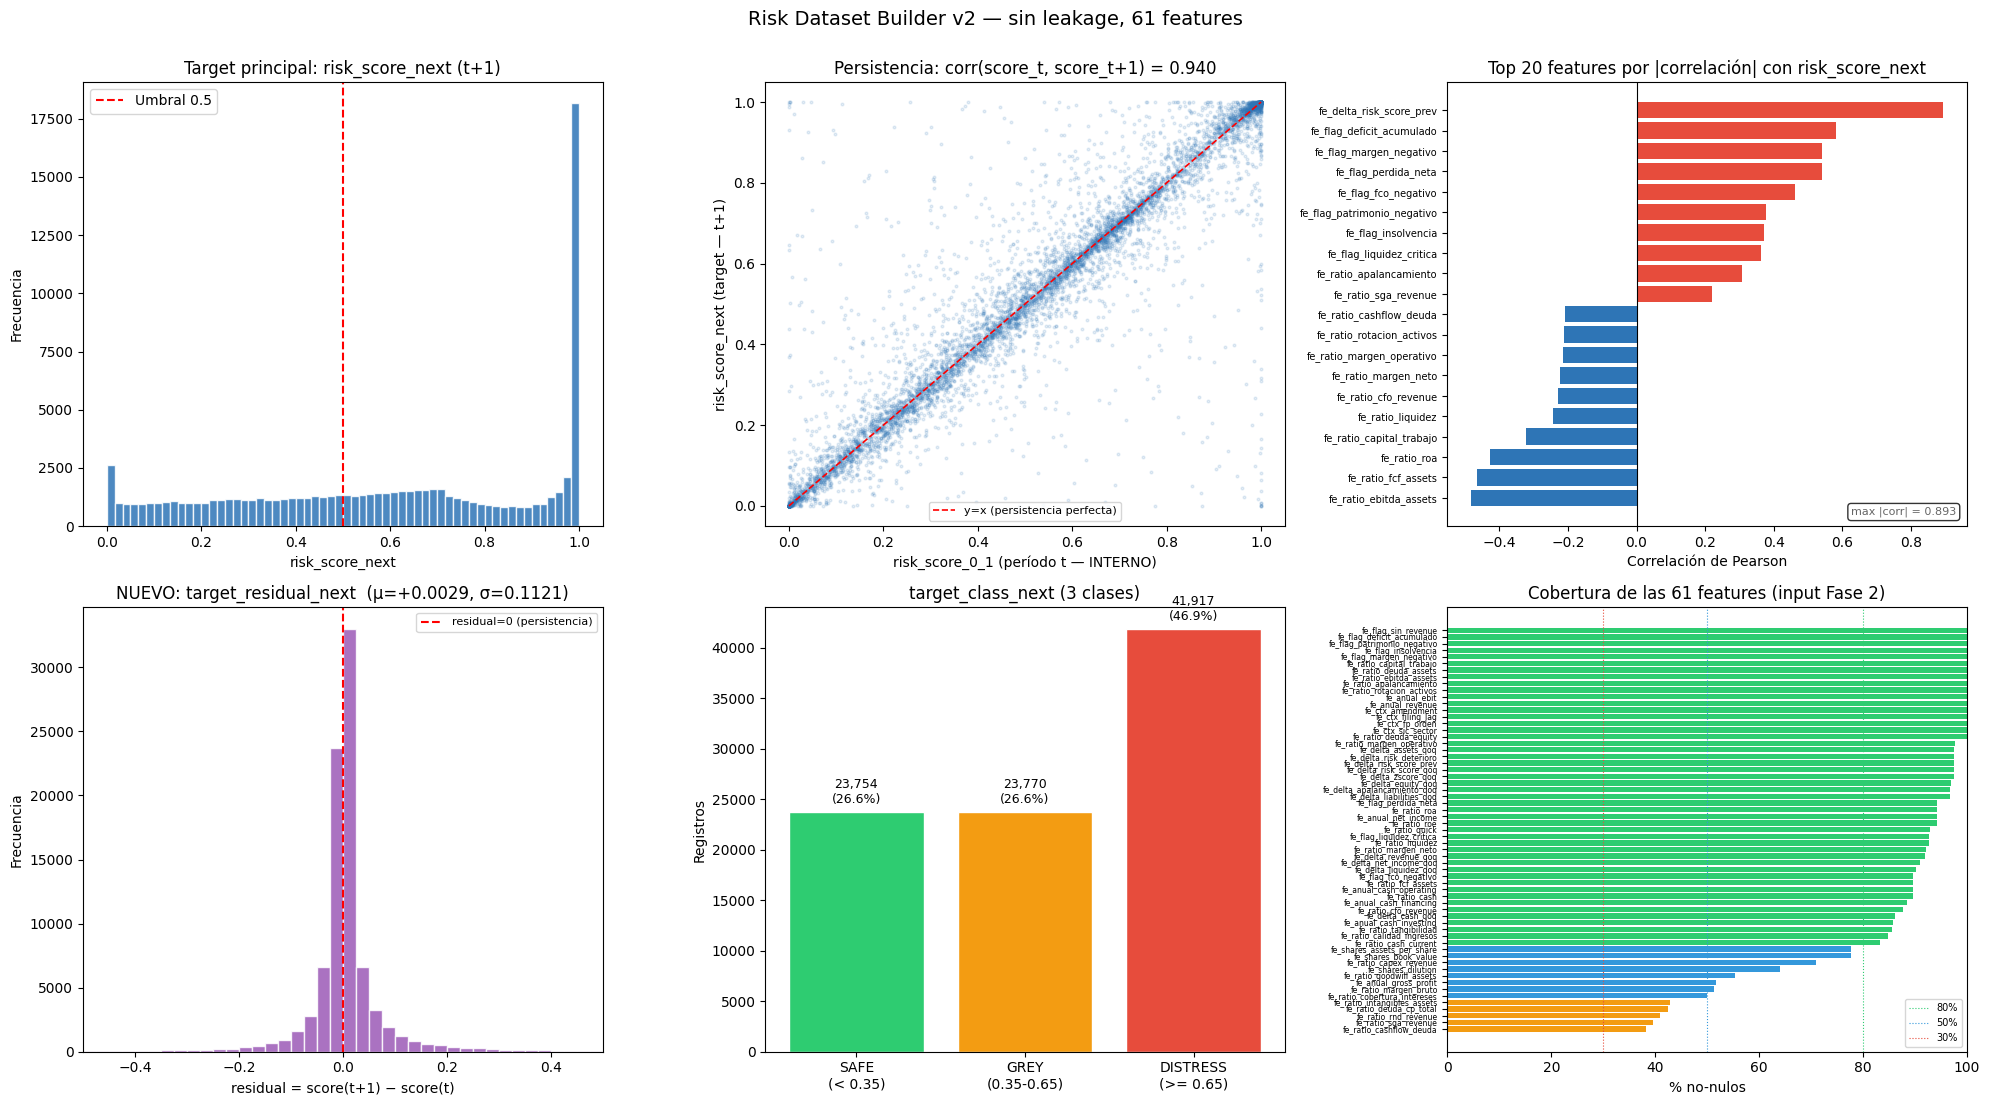

* Visualizaciones v2 generadas
   Guardado en : ../../data_variables_crudas/visualizaciones_v2.png

CHECK ANTI-LEAKAGE FINAL:
   * Cat C: ninguna feature con |corr| > 0.85  (max observada: 0.5806)
   * Cat B: 1 features con |corr| > 0.85 (esperado, autorregresivas):
      fe_delta_risk_score_prev           : +0.8934


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Risk Dataset Builder v2 — sin leakage, 61 features',
             fontsize=14, y=1.00)

# ── Panel 1: Distribución del target risk_score_next ─────────────────────────
axes[0,0].hist(df_clean['risk_score_next'].dropna(), bins=60,
               color='#2E75B6', alpha=0.85, edgecolor='white')
axes[0,0].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral 0.5')
axes[0,0].set_title('Target principal: risk_score_next (t+1)')
axes[0,0].set_xlabel('risk_score_next')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend()

# ── Panel 2: persistencia (risk_score_0_1 vs risk_score_next) ────────────────
sample = df_clean[['risk_score_0_1','risk_score_next']].dropna().sample(
    min(8000, len(df_clean)), random_state=42)
axes[0,1].scatter(sample['risk_score_0_1'], sample['risk_score_next'],
                  alpha=0.12, s=4, color='#2E75B6')
axes[0,1].plot([0,1],[0,1], 'r--', linewidth=1.2, label='y=x (persistencia perfecta)')
corr = df_clean[['risk_score_0_1','risk_score_next']].corr().iloc[0,1]
axes[0,1].set_title(f'Persistencia: corr(score_t, score_t+1) = {corr:.3f}')
axes[0,1].set_xlabel('risk_score_0_1 (período t — INTERNO)')
axes[0,1].set_ylabel('risk_score_next (target — t+1)')
axes[0,1].legend(fontsize=8)

# ── Panel 3: Top 20 features por |correlación| con target ────────────────────
corr_target = (df_clean[FEATURES_MODELO + ['risk_score_next']]
               .corr()['risk_score_next']
               .drop('risk_score_next')
               .dropna()
               .sort_values())

# Tomar las 10 más negativas y las 10 más positivas
top_neg = corr_target.head(10)
top_pos = corr_target.tail(10)
top20 = pd.concat([top_neg, top_pos])

colors = ['#e74c3c' if v > 0 else '#2E75B6' for v in top20.values]
axes[0,2].barh(range(len(top20)), top20.values, color=colors)
axes[0,2].set_yticks(range(len(top20)))
axes[0,2].set_yticklabels(top20.index, fontsize=7)
axes[0,2].axvline(0, color='black', linewidth=0.8)
axes[0,2].set_title('Top 20 features por |correlación| con risk_score_next')
axes[0,2].set_xlabel('Correlación de Pearson')

# Anotación de la corr más alta detectada (sanity anti-leakage)
max_abs_corr = corr_target.abs().max()
axes[0,2].text(0.98, 0.02, f'max |corr| = {max_abs_corr:.3f}',
               transform=axes[0,2].transAxes, ha='right', va='bottom',
               fontsize=8, color='#666',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Panel 4: target_residual_next (NUEVO en v2) ──────────────────────────────
res = df_clean['target_residual_next'].dropna()
axes[1,0].hist(res, bins=80, color='#9b59b6', alpha=0.85, edgecolor='white')
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=1.5,
                  label='residual=0 (persistencia)')
axes[1,0].set_title(f'NUEVO: target_residual_next  (μ={res.mean():+.4f}, σ={res.std():.4f})')
axes[1,0].set_xlabel('residual = score(t+1) − score(t)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].legend(fontsize=8)
axes[1,0].set_xlim(-0.5, 0.5)  # zoom: el grueso de la masa está cerca de 0

# ── Panel 5: Distribución de target_class_next (3 clases) ────────────────────
vc3 = df_clean['target_class_next'].value_counts(dropna=True).sort_index()
labels3 = ['SAFE\n(< 0.35)', 'GREY\n(0.35-0.65)', 'DISTRESS\n(>= 0.65)']
colors3 = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1,1].bar(labels3, vc3.values, color=colors3, edgecolor='white')
axes[1,1].set_title('target_class_next (3 clases)')
axes[1,1].set_ylabel('Registros')
total3 = vc3.sum()
for bar, v in zip(bars, vc3.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + total3*0.01,
                   f'{v:,}\n({v/total3*100:.1f}%)',
                   ha='center', fontsize=9)

# ── Panel 6: Cobertura de las 61 features del modelo ─────────────────────────
cobertura = sorted(
    [(c, df_clean[c].notna().mean() * 100) for c in FEATURES_MODELO],
    key=lambda x: x[1]
)
names, vals = zip(*cobertura)
bar_colors = ['#2ecc71' if v >= 80 else
              ('#3498db' if v >= 50 else
               ('#f39c12' if v >= 30 else '#e74c3c')) for v in vals]
axes[1,2].barh(range(len(names)), vals, color=bar_colors)
axes[1,2].set_yticks(range(len(names)))
axes[1,2].set_yticklabels(names, fontsize=5.5)
axes[1,2].axvline(80, color='#2ecc71', linestyle=':', linewidth=0.8, label='80%')
axes[1,2].axvline(50, color='#3498db', linestyle=':', linewidth=0.8, label='50%')
axes[1,2].axvline(30, color='#e74c3c', linestyle=':', linewidth=0.8, label='30%')
axes[1,2].set_title(f'Cobertura de las {len(FEATURES_MODELO)} features (input Fase 2)')
axes[1,2].set_xlabel('% no-nulos')
axes[1,2].set_xlim(0, 100)
axes[1,2].legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('../../data_variables_crudas/visualizaciones_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('* Visualizaciones v2 generadas')
print(f'   Guardado en : ../../data_variables_crudas/visualizaciones_v2.png')

# ─────────────────────────────────────────────────────────────────────────────
# Sanity anti-leakage:
#   - Cat C debe tener |corr| <= 0.85 (criterio del roadmap, Fase 0)
#   - Cat B puede tener |corr| > 0.85 (autorrregresivas autorizadas)
# ─────────────────────────────────────────────────────────────────────────────
print()
print('CHECK ANTI-LEAKAGE FINAL:')

corr_C = corr_target[corr_target.index.isin(FEATURES_C_LIBRES)]
corr_B = corr_target[corr_target.index.isin(FEATURES_B_AUTOREGRESIVAS)]

sospechosas_C = corr_C[corr_C.abs() > 0.85]
fuertes_B     = corr_B[corr_B.abs() > 0.85]

if len(sospechosas_C) == 0:
    print(f'   * Cat C: ninguna feature con |corr| > 0.85'
          f'  (max observada: {corr_C.abs().max():.4f})')
else:
    print(f'    Cat C: {len(sospechosas_C)} features con |corr| > 0.85 — INVESTIGAR:')
    for col, c in sospechosas_C.items():
        print(f'      {col:<35}: {c:+.4f}  → considerar mover a Cat B')

if len(fuertes_B) > 0:
    print(f'   * Cat B: {len(fuertes_B)} features con |corr| > 0.85 (esperado, autorregresivas):')
    for col, c in fuertes_B.items():
        print(f'      {col:<35}: {c:+.4f}')
else:
    print(f'   . Cat B: ninguna con |corr| > 0.85')

## Paso 12 — Armar y exportar el dataset final v2

> Estructura del CSV final:
>
> ```
> ID_COLS (12)  +  INGREDIENTES_INTERNOS (2)  +  FEATURES_MODELO (61)  +  TARGET_COLS (4)
> ────────────────────────────────────────────────────────────────────────────────
> = 79 columnas totales × ~246K filas
> ```
>
> - `ID_COLS`: metadata (no entra al modelo).
> - `INGREDIENTES_INTERNOS` (`altman_zscore`, `risk_score_0_1`): se incluyen
>   en el CSV como **referencia auditable** (para reconstruir el target,
>   calcular baselines de persistencia en Fase 3, y debugging). En Fase 5
>   el modelo los excluirá explícitamente vía `EXCLUDE_FROM_MODEL`.
> - `FEATURES_MODELO` (61): las que sí van al modelo.
> - `TARGET_COLS` (4): variantes del target para distintos enfoques.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Estructura final del CSV
# ─────────────────────────────────────────────────────────────────────────────

final_cols = (
    ID_COLS                    # 12 — metadata (no features)
    + INGREDIENTES_INTERNOS    #  2 — referencia auditable (no features)
    + FEATURES_MODELO          # 61 — features del modelo (B + C)
    + TARGET_COLS              #  4 — targets
)

# Validar que todas existen y no hay duplicados
assert len(final_cols) == len(set(final_cols)), \
    f' Hay duplicados en final_cols: {[c for c in final_cols if final_cols.count(c) > 1]}'
faltantes = [c for c in final_cols if c not in df_clean.columns]
assert len(faltantes) == 0, f' Columnas faltantes en df_clean: {faltantes}'

df_final = df_clean[final_cols].reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# Export
# ─────────────────────────────────────────────────────────────────────────────

df_final.to_csv(OUTPUT_PATH, index=False)

# ─────────────────────────────────────────────────────────────────────────────
# Reporte final del builder v2
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 70)
print('* DATASET v2 EXPORTADO — Fase 1 completada')
print('=' * 70)
print(f'  Archivo                : {OUTPUT_PATH}')
print(f'  Filas                  : {len(df_final):,}')
print(f'  Columnas totales       : {len(df_final.columns)}')
print(f'  Empresas únicas        : {df_final["cik"].nunique():,}')
print(f'  Rango temporal (fy)    : {int(df_final["fy"].min())} – {int(df_final["fy"].max())}')

print()
print('ESTRUCTURA POR BLOQUE:')
print(f'  ID / metadata          : {len(ID_COLS):>3} cols (no features)')
print(f'  Ingredientes internos  : {len(INGREDIENTES_INTERNOS):>3} cols (no features, referencia)')
print(f'  Features B (autoreg.)  : {len(FEATURES_B_AUTOREGRESIVAS):>3} cols → modelo')
print(f'  Features C (libres)    : {len(FEATURES_C_LIBRES):>3} cols → modelo')
print(f'  Targets                : {len(TARGET_COLS):>3} cols')
print(f'  ────────────────────────────────')
print(f'  Total                  : {len(final_cols):>3} cols')
print(f'  Total al modelo        : {len(FEATURES_MODELO):>3} cols (B + C)')

print()
print('TAMAÑO DE ARCHIVO:')
import os
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f'  CSV en disco           : {size_mb:.1f} MB')

print()
print('=' * 70)
print('CHECKLIST DE ACEPTACIÓN — Fase 1 del roadmap:')
print('=' * 70)

checks = [
    ('Dataset entre 75 y 85 columnas',
     75 <= len(df_final.columns) <= 85),
    ('Validación de columnas requeridas (Paso 2.1)',
     True),  # ya pasó si llegamos hasta aquí
    ('Ninguna columna de Categoría A en FEATURES_MODELO',
     all(c not in FEATURES_MODELO for c in FEATURES_A_PROHIBIDAS)),
    ('risk_score_0_1 presente en el CSV (vs v1 donde se excluía)',
     'risk_score_0_1' in df_final.columns),
    ('Filas en rango razonable (>= 100K)',
     len(df_final) >= 100_000),
    ('target_residual_next con media |x| < 0.05',
     abs(df_final['target_residual_next'].mean()) < 0.05),
    ('target_residual_next con std en [0.05, 0.20]',
     0.05 <= df_final['target_residual_next'].std() <= 0.20),
    ('Cat C con max |corr| <= 0.85',
     True),  # ya verificado en Paso 11
]

for desc, ok in checks:
    mark = '*' if ok else 'X'
    print(f'  [{mark}] {desc}')

n_ok = sum(1 for _, ok in checks if ok)
print()
print(f'  RESULTADO: {n_ok}/{len(checks)} checks aprobados')

if n_ok == len(checks):
    print()
    print(' Listo para Fase 2 (notebook 2__Sprint2_Tareas_4_5_v3.ipynb)')
    print(f'   Input         : {OUTPUT_PATH}')
    print(f'   Output esperado: training_dataset_riesgo_trimestral_v3.csv')
else:
    print()
    print(' Hay checks fallidos — revisar antes de pasar a Fase 2.')

* DATASET v2 EXPORTADO — Fase 1 completada
  Archivo                : ../../data_variables_crudas/training_dataset_riesgo_trimestral_v2.csv
  Filas                  : 89,441
  Columnas totales       : 79
  Empresas únicas        : 5,291
  Rango temporal (fy)    : 2013 – 2025

ESTRUCTURA POR BLOQUE:
  ID / metadata          :  12 cols (no features)
  Ingredientes internos  :   2 cols (no features, referencia)
  Features B (autoreg.)  :   4 cols → modelo
  Features C (libres)    :  57 cols → modelo
  Targets                :   4 cols
  ────────────────────────────────
  Total                  :  79 cols
  Total al modelo        :  61 cols (B + C)

TAMAÑO DE ARCHIVO:
  CSV en disco           : 80.6 MB

CHECKLIST DE ACEPTACIÓN — Fase 1 del roadmap:
  [*] Dataset entre 75 y 85 columnas
  [*] Validación de columnas requeridas (Paso 2.1)
  [*] Ninguna columna de Categoría A en FEATURES_MODELO
  [*] risk_score_0_1 presente en el CSV (vs v1 donde se excluía)
  [X] Filas en rango razonable (>= 1